## Day 2 — Multiple Linear Regression

In [159]:
# import all the library using in this project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [101]:
# Load local Dataset
df=pd.read_csv("../data/Salary_Data.csv")

In [102]:
# check 5 row
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [103]:
# understand the column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


In [104]:
# know the row and column
print(df.shape)

(6704, 6)


In [105]:
# check the null value
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [106]:
# to know the statistics
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [107]:
# remove the salary column
df=df.dropna(subset=["Salary"])

In [108]:
# now check
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,1
Job Title,0
Years of Experience,0
Salary,0


In [109]:
df['Education Level']=df['Education Level'].fillna(
    df['Education Level'].mode()[0]
)

In [110]:
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [111]:
# check duplicated data
df.duplicated().sum()

np.int64(4911)

In [112]:
# remove the duplicated data
df=df.drop_duplicates()

In [113]:
# verfiy the duplicated data
print("Duplicates after cleaning :",df.duplicated().sum())

Duplicates after cleaning : 0


In [115]:
# check the row and column
df.shape

(1788, 6)

In [116]:
# To see how many categories we have
df['Gender'].value_counts()

,count
Gender,
Male,967
Female,814
Other,7


In [117]:
df['Education Level'].value_counts()

,count
Education Level,
Bachelor's Degree,507
Master's Degree,446
PhD,340
Bachelor's,262
Master's,122
High School,110
phD,1


In [118]:
df['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD', "Bachelor's Degree",
       "Master's Degree", 'High School', 'phD'], dtype=object)

In [119]:
df = df.copy()

In [120]:
# creating a mapping
education_mapping={
    "Bachelor's Degree":"Bachelor's",
    "Bachelor's":"Bachelor's",

    "Master's Degree":"Master's",
    "Master's":"Master's",

    "PhD":"PhD",
    "phD":"PhD",

    "High School":"High School"
}

In [121]:
df['Education Level']=df['Education Level'].replace(education_mapping)

In [122]:
df['Education Level'].value_counts()

,count
Education Level,
Bachelor's,769
Master's,568
PhD,341
High School,110


In [123]:
df['Job Title'].unique()

array(['Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Manager',
      

In [124]:
df['Job Title'].shape

(1788,)

In [125]:
# find the how many categories are

calegorical_cols=df.select_dtypes(include="object").columns

for col in calegorical_cols:
  print(col, "-",df[col].value_counts(),"unique categories")

Gender - Gender
Male      967
Female    814
Other       7
Name: count, dtype: int64 unique categories
Education Level - Education Level
Bachelor's     769
Master's       568
PhD            341
High School    110
Name: count, dtype: int64 unique categories
Job Title - Job Title
Software Engineer Manager             127
Full Stack Engineer                   122
Senior Software Engineer               96
Senior Project Engineer                95
Back end Developer                     81
                                     ... 
Junior Social Media Specialist          1
Senior Product Development Manager      1
Developer                               1
Social Media Man                        1
Delivery Driver                         1
Name: count, Length: 192, dtype: int64 unique categories


In [126]:
df['Job Title'].value_counts().head(20)

,count
Job Title,
Software Engineer Manager,127
Full Stack Engineer,122
Senior Software Engineer,96
Senior Project Engineer,95
Back end Developer,81
Data Scientist,80
Software Engineer,78
Front end Developer,71
Marketing Manager,55


In [127]:
counts= df['Job Title'].value_counts()
print(counts[counts <= 2])

Job Title
Juniour HR Generalist                 2
Senior Operations Coordinator         2
Senior Data Engineer                  2
Juniour HR Coordinator                2
Senior Sales Manager                  2
                                     ..
Junior Social Media Specialist        1
Senior Product Development Manager    1
Developer                             1
Social Media Man                      1
Delivery Driver                       1
Name: count, Length: 108, dtype: int64


In [128]:
# Find capitalization problems automatically
df['Education Level'].str.lower().value_counts()

,count
Education Level,
bachelor's,769
master's,568
phd,341
high school,110


In [129]:
df['Job Title'].str.strip().str.lower().value_counts()

,count
Job Title,
software engineer manager,127
full stack engineer,122
senior software engineer,96
senior project engineer,95
back end developer,81
...,...
junior research scientist,1
senior product development manager,1
developer,1


In [130]:
for col in calegorical_cols:
  print("\n","="*40)
  print(col)
  print("Unique :",df[col].unique())
  print(df[col].value_counts().head())


Gender
Unique : ['Male' 'Female' 'Other']
Gender
Male      967
Female    814
Other       7
Name: count, dtype: int64

Education Level
Unique : ["Bachelor's" "Master's" 'PhD' 'High School']
Education Level
Bachelor's     769
Master's       568
PhD            341
High School    110
Name: count, dtype: int64

Job Title
Unique : ['Software Engineer' 'Data Analyst' 'Senior Manager' 'Sales Associate'
 'Director' 'Marketing Analyst' 'Product Manager' 'Sales Manager'
 'Marketing Coordinator' 'Senior Scientist' 'Software Developer'
 'HR Manager' 'Financial Analyst' 'Project Manager' 'Customer Service Rep'
 'Operations Manager' 'Marketing Manager' 'Senior Engineer'
 'Data Entry Clerk' 'Sales Director' 'Business Analyst' 'VP of Operations'
 'IT Support' 'Recruiter' 'Financial Manager' 'Social Media Specialist'
 'Software Manager' 'Junior Developer' 'Senior Consultant'
 'Product Designer' 'CEO' 'Accountant' 'Data Scientist'
 'Marketing Specialist' 'Technical Writer' 'HR Generalist'
 'Project Engi

In [131]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("\n" + "=" * 50)
    print("COLUMN:", col)
    print("UNIQUE CATEGORIES:", df[col].nunique())
    print("\nTOP 20:")
    print(df[col].value_counts().head(20))


COLUMN: Gender
UNIQUE CATEGORIES: 3

TOP 20:
Gender
Male      967
Female    814
Other       7
Name: count, dtype: int64

COLUMN: Education Level
UNIQUE CATEGORIES: 4

TOP 20:
Education Level
Bachelor's     769
Master's       568
PhD            341
High School    110
Name: count, dtype: int64

COLUMN: Job Title
UNIQUE CATEGORIES: 192

TOP 20:
Job Title
Software Engineer Manager    127
Full Stack Engineer          122
Senior Software Engineer      96
Senior Project Engineer       95
Back end Developer            81
Data Scientist                80
Software Engineer             78
Front end Developer           71
Marketing Manager             55
Product Manager               53
Data Analyst                  51
Web Developer                 34
Financial Manager             28
Director of HR                27
Director of Marketing         27
Marketing Coordinator         26
Junior Sales Associate        25
Content Marketing Manager     24
Operations Manager            22
Software Developer

In [132]:
job_counts = df['Job Title'].value_counts()

print("Jobs appearing once:", (job_counts == 1).sum())
print("Jobs appearing <= 2:", (job_counts <= 2).sum())
print("Jobs appearing <= 5:", (job_counts <= 5).sum())

Jobs appearing once: 84
Jobs appearing <= 2: 108
Jobs appearing <= 5: 138


In [133]:
df=df.copy()

In [134]:
df['Job Title'] =df['Job Title'].where(
    df['Job Title'].map(job_counts) > 5,
    "Other"
)

In [135]:
df['Job Title'].unique()

array(['Software Engineer', 'Data Analyst', 'Other', 'Sales Associate',
       'Marketing Analyst', 'Product Manager', 'Sales Manager',
       'Marketing Coordinator', 'Software Developer', 'Financial Analyst',
       'Project Manager', 'Operations Manager', 'Marketing Manager',
       'Sales Director', 'Financial Manager', 'Product Designer',
       'Data Scientist', 'Sales Executive', 'Director of Marketing',
       'Graphic Designer', 'Director of Operations',
       'Senior Data Scientist', 'Digital Marketing Manager',
       'Senior Financial Analyst', 'Web Developer', 'Research Director',
       'Senior Software Engineer', 'Content Marketing Manager',
       'Sales Representative', 'Senior Project Manager',
       'Senior Marketing Manager', 'Research Scientist',
       'Junior Software Developer', 'Junior Web Developer',
       'Senior Business Analyst', 'Junior HR Generalist',
       'Senior HR Generalist', 'Junior Sales Representative',
       'Junior Marketing Manager', 'Seni

In [136]:
df['Job Title'].value_counts()

,count
Job Title,
Other,237
Software Engineer Manager,127
Full Stack Engineer,122
Senior Software Engineer,96
Senior Project Engineer,95
Back end Developer,81
Data Scientist,80
Software Engineer,78
Front end Developer,71


In [137]:
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Other,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Other,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Other,10.0,110000.0


In [138]:
# numerical
numerical_features=[
    "Age",
    "Years of Experience"
]

In [139]:
categorical_features=[
    "Gender",
    "Education Level",
    "Job Title"
]

In [140]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num","passthrough",numerical_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1788 entries, 0 to 6631
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1788 non-null   float64
 1   Gender               1788 non-null   object 
 2   Education Level      1788 non-null   object 
 3   Job Title            1788 non-null   object 
 4   Years of Experience  1788 non-null   float64
 5   Salary               1788 non-null   float64
dtypes: float64(3), object(3)
memory usage: 97.8+ KB


In [142]:
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Other,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Other,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Other,10.0,110000.0


In [143]:
# create a x and y
x = df[
    [
        "Age",
        "Gender",
        "Education Level",
        "Job Title",
        "Years of Experience"
    ]
]

y = df["Salary"]

In [144]:
x.head()

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,Male,Bachelor's,Software Engineer,5.0
1,28.0,Female,Master's,Data Analyst,3.0
2,45.0,Male,PhD,Other,15.0
3,36.0,Female,Bachelor's,Sales Associate,7.0
4,52.0,Male,Master's,Other,20.0


In [145]:
y.head()

,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


In [146]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,

    random_state=42
)

In [147]:
# check the sizes

print("x-train :",x_train.shape)
print("x-test :",x_test.shape)

print("y-train :",y_train.shape)
print("y-test :",y_test.shape)


x-train : (1430, 5)
x-test : (358, 5)
y-train : (1430,)
y-test : (358,)


In [148]:
# create the model
model=Pipeline([
    ("preprocessor",preprocessor),
    ("regressor",LinearRegression())
])

In [149]:
# Train the Model
model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Age',
                                                   'Years of Experience']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Education Level',
                                                   'Job Title'])])),
                ('regressor', LinearRegression())])

## Make predictions on test data

In [150]:
y_pred=model.predict(x_test)

In [151]:
print(y_pred[:10])

[ 57803.48771572 143447.79098154 167554.45971521  49877.67656996
  22779.20112035 115751.37430666  98611.35862125 138320.99261791
 114564.19404952 134465.72669057]


In [168]:
# compare prediction vs actual
comparison = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted Salary":y_pred
})

print(comparison.head(10))

     Actual  Predicted Salary
0   65000.0      57803.487716
1  100000.0     143447.790982
2  180000.0     167554.459715
3   50000.0      49877.676570
4   25000.0      22779.201120
5  140000.0     115751.374307
6  100000.0      98611.358621
7  100000.0     138320.992618
8  145000.0     114564.194050
9  135000.0     134465.726691


In [155]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower)
print("Upper:", upper)

Q1: 70000.0
Q3: 160000.0
IQR: 90000.0
Lower: -65000.0
Upper: 295000.0


In [157]:
outliers = df[
    (df["Salary"] < lower) |
    (df["Salary"] > upper)
]

print("Number of salary outliers:", len(outliers))
print(outliers[["Age", "Education Level", "Job Title",
                "Years of Experience", "Salary"]])

Number of salary outliers: 0
Empty DataFrame
Columns: [Age, Education Level, Job Title, Years of Experience, Salary]
Index: []


In [158]:
print(df[[
    "Age",
    "Years of Experience",
    "Salary"
]].corr())

                          Age  Years of Experience    Salary
Age                  1.000000             0.936152  0.766758
Years of Experience  0.936152             1.000000  0.818732
Salary               0.766758             0.818732  1.000000


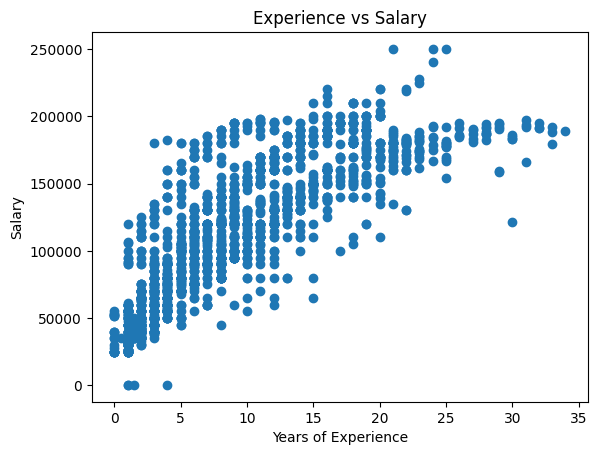

In [153]:
plt.scatter(df["Years of Experience"], df["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

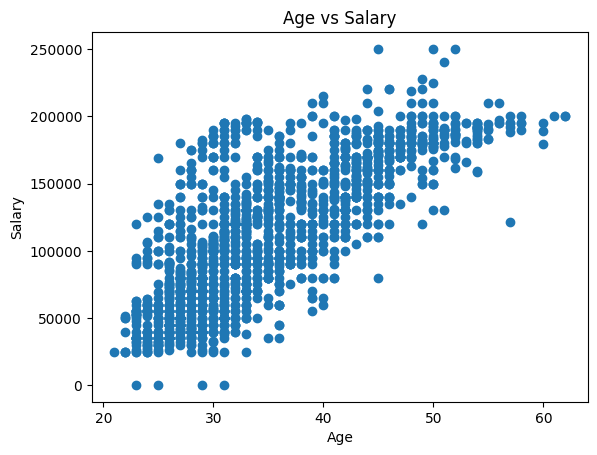

In [154]:
plt.scatter(df["Age"], df["Salary"])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

In [160]:
# mean absolute error

mae=mean_absolute_error(y_test,y_pred)
print("MAE :",mae)

MAE : 15309.955161805281


In [161]:
# Mean Square Error

mse=mean_squared_error(y_test,y_pred)
print("MSE :",mse)

MSE : 432230030.6582642


In [162]:
# Root Mean Square Error

rmse = mean_squared_error(
    y_test,
    y_pred,
)**0.5

print("RMSE :",rmse)

RMSE : 20790.142631984618


In [163]:
# by using numpy to check

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE :",rmse)


RMSE : 20790.142631984618


In [164]:
# R-Squared

r2=r2_score(y_test,y_pred)
print("R2 :",r2)

R2 : 0.8419361922322479


In [169]:
# Analyze the error
comparison["Error"]=(
    comparison["Actual"]-comparison["Predicted Salary"]
)

In [171]:
comparison["Absolute Error"]=comparison["Error"].abs()

In [172]:
# find the worst predictions

worst = comparison.sort_values(
    "Absolute Error",ascending=False
)

print(worst.head())

       Actual  Predicted Salary         Error  Absolute Error
179  250000.0     162352.862174  87647.137826    87647.137826
250  210000.0     142670.198451  67329.801549    67329.801549
313  180000.0     115043.642312  64956.357688    64956.357688
94   190000.0     133589.388407  56410.611593    56410.611593
320  180000.0     124462.997639  55537.002361    55537.002361


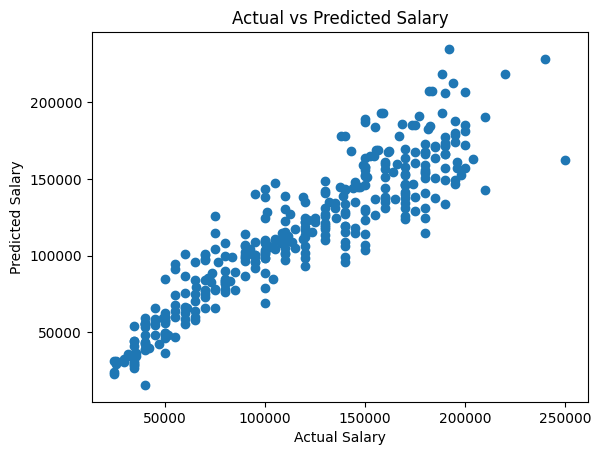

In [173]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

## Test a completely NEW employee

In [174]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Gender": ["Male"],
    "Education Level": ["Master's"],
    "Job Title": ["Data Analyst"],
    "Years of Experience": [5]
})

In [175]:
prediction = model.predict(new_employee)

print("Predicted Salary:", prediction[0])

Predicted Salary: 132981.7503808174


In [176]:
# create multiple new employees
new_employees = pd.DataFrame({
    "Age": [25, 30, 35, 40, 45],
    "Gender": ["Female", "Male", "Female", "Male", "Female"],
    "Education Level": [
        "Bachelor's",
        "Master's",
        "Master's",
        "PhD",
        "PhD"
    ],
    "Job Title": [
        "Data Analyst",
        "Software Engineer",
        "Data Scientist",
        "Software Engineer Manager",
        "Data Scientist"
    ],
    "Years of Experience": [2, 5, 8, 15, 20]
})

predictions = model.predict(new_employees)

for i, salary in enumerate(predictions):
    print(f"Employee {i+1}: ${salary:,.2f}")

Employee 1: $101,517.64
Employee 2: $121,011.63
Employee 3: $147,319.43
Employee 4: $155,547.63
Employee 5: $202,308.75


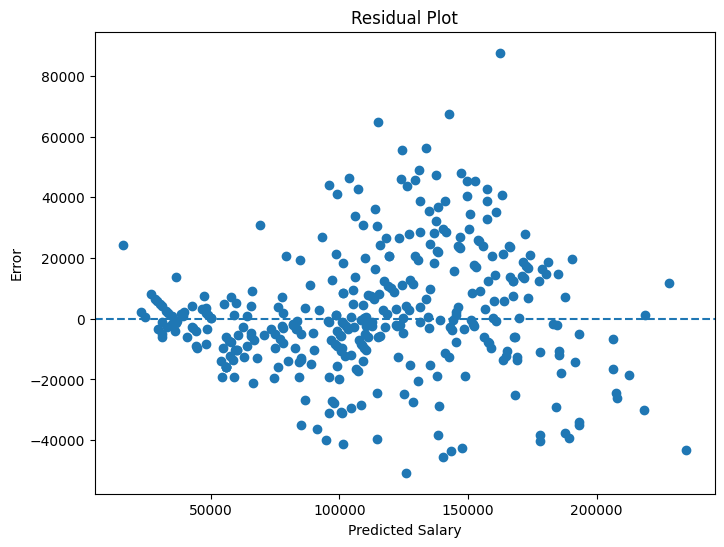

In [178]:
#  create a residual/error plot
errors = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, errors)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Salary")
plt.ylabel("Error")
plt.title("Residual Plot")

plt.show()

In [179]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Score": [mae, mse, rmse, r2]
})

print(metrics)

  Metric         Score
0    MAE  1.530996e+04
1    MSE  4.322300e+08
2   RMSE  2.079014e+04
3     R²  8.419362e-01


In [177]:
import joblib

joblib.dump(model, "salary_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
